In [9]:
import locale
import os

os.environ["PYTHONUTF8"] = "1"
os.environ["PYTHONIOENCODING"] = "utf-8"
locale.getpreferredencoding = lambda do_setlocale=True: "UTF-8"

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

In [4]:
X, y_true = make_moons(n_samples=500, noise=0.05, random_state=42)

In [6]:
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [10]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_label = kmeans.fit_predict(X_scaled)

In [11]:
df['kmeans_cluster'] = kmeans_label

**<h4>This is the problem with the k means it cannot divide the clusters in some type of dataset </h4>**
( which do not give circular shape or the dataset)

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

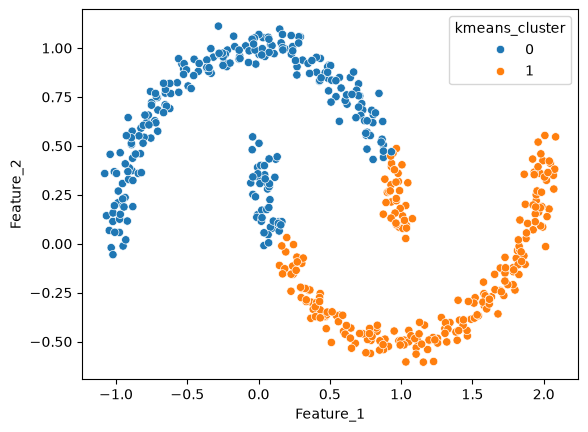

In [12]:
sns.scatterplot(x=df['Feature_1'], y = df['Feature_2'], hue = df['kmeans_cluster'], palette='tab10')

**But, DBSCAN will not have such issue it will use eps and min samples to correctly separate the clusters**

In [13]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [15]:
df['dbscan_clusters'] = dbscan_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

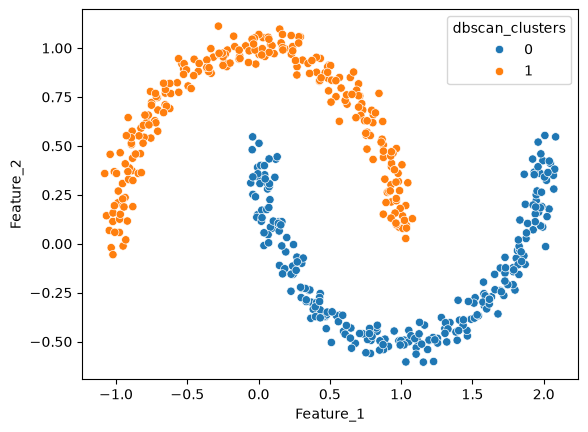

In [17]:
sns.scatterplot(x=df['Feature_1'], y = df['Feature_2'], hue = df['dbscan_clusters'], palette='tab10')